In [1]:
import os
import json
from glob import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
import utils2

In [2]:
PHENOTYPE_PATH = os.path.join(utils2.DATASET_PATH, 'phenotype', 'phenotype_preprocessed.tsv')
HOLDOUTS30_PATH = os.path.join(utils2.HOLDOUTS_PATH, '30_holdouts_new2')
SUBJECTS_PATH = os.path.join(utils2.DATASET_PATH, 'sub-*')
CONTRAST_NAME = 'incongruent_vs_congruent'
ALT_TEST = 'Incongruent > Congruent'
ALPHA1 = 0.01
ALPHA2 = 0.05
ALPHA3 = 0.1
HEIGHT_CONTROL1 = 'fpr'
HEIGHT_CONTROL2 = 'fdr'
CLUSTER_THRESHOLD1 = 10
CLUSTER_THRESHOLD2 = 20
CLUSTER_THRESHOLD3 = 25
CLUSTER_THRESHOLD4 = 30
ATLAS1 = 'schaefer'
N_ROIS1 = 1000
YN1 = 17
FEATURE_TABLE_NAME = 'ML_Dataset'
CONSENSUS_THRESHOLDS = [0.7, 0.8, 0.9]

In [3]:
# --- paths for logging and consensus tracking ----------------------------------
LOG_PATH = os.path.join(HOLDOUTS30_PATH, 'iteration_log.jsonl')
ROI_COUNTS_PATH = os.path.join(HOLDOUTS30_PATH, 'roi_occurrence.json')
CONSENSUS_ROIS_PATH = os.path.join(HOLDOUTS30_PATH, 'threshold_wise_consensus_rois.json')

In [4]:
holdouts_info = utils2.load_file(HOLDOUTS30_PATH, 'holdouts30_split_ids.json')
phenotype = pd.read_csv(PHENOTYPE_PATH, delimiter='\t')

Resuming... 0 valid iterations already completed
Alpha: 0.01, Height control: fpr, Cluster threshold: 25
0 unique ROIs seen so far

Holdout ID: 01
Computed group mean task-fmri
Subjects completed:
24139, 24212, 22956, 23910, 22354, 22268, 24151, 23996, 21214, 24073, 23749, 22353, 23483, 23979, 22477, 23353, 23883, 23494, 24015, 23362, 23261, 24033, 23855, 23972, 23014, 23568, 22487, 23532, 24004, 24021, 24353, 23376, 23971, 23865, 23762, 24240, 22630, 23442, 22871, 22587, 20131, 22818, 23010, 24089, 23631, 24067, 24145, 24038, 24017, 22734, 20725, 23878, 23545, 23407, 24091, 23534, 24236, 22873, 22380, 22475, 
Obtained first-level contrast maps
Created second-level design matrix
Obtained Group mean task maps


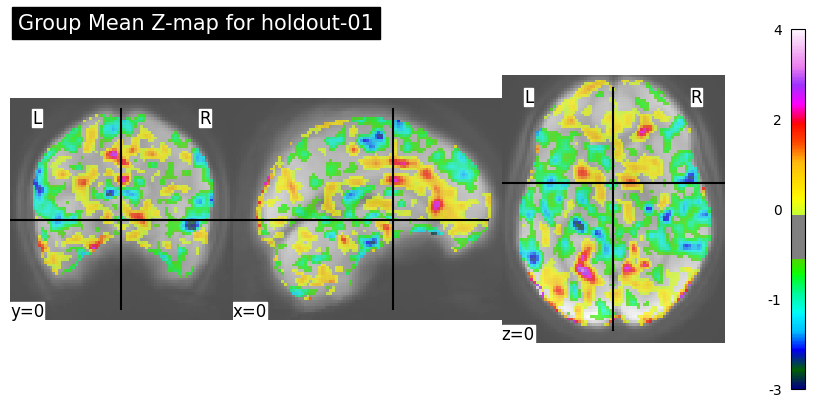

Threshold: 2.576
Thresholded the group-task-mean Z-map
Fetched resampled atlas map, labels, and coordinates
Applied atlas on Z-map
Obtained group ROIs mask, labels, and coordinates


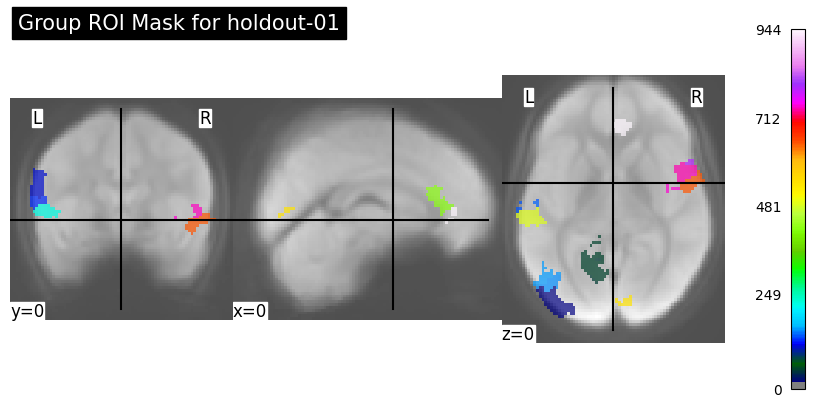

124 ROIs found
Subjects completed:
22829, 22831, 22847, 22860, 22862, 22906, 23028, 23044, 23072, 23123, 23257, 23294, 23303, 23314, 23317, 23342, 23381, 23382, 23386, 23392, 23432, 23480, 23485, 23501, 23524, 23559, 23567, 23572, 23584, 23601, 23622, 23629, 23664, 23690, 23735, 23779, 23822, 23842, 23871, 23892, 23923, 23925, 23946, 23985, 23986, 23987, 23991, 24022, 24029, 24039, 24040, 24046, 24050, 24106, 24115, 24118, 24127, 24142, 24146, 24148, 24182, 24197, 24198, 24217, 24260, 24270, 24275, 24276, 24300, 22172, 20209, 21100, 21508, 22281, 22286, 22295, 22346, 22365, 22366, 22381, 22482, 22494, 22532, 22536, 22600, 22623, 22686, 22687, 22727, 
Created ML Features table
Shape of ML Dataset: (89, 7751)


,participant_id,LH_VisCent_ExStr_1,LH_VisCent_ExStr_2,LH_VisCent_ExStr_3,LH_VisCent_ExStr_7,LH_VisCent_ExStr_9,LH_VisCent_ExStr_12,LH_VisCent_ExStr_14,LH_VisCent_ExStr_16,LH_VisCent_ExStr_17,...,RH_SalVentAttnA_Ins_5_to_RH_SalVentAttnB_Ins_9,RH_SalVentAttnA_Ins_5_to_RH_DefaultA_PFCm_7,RH_SalVentAttnA_Ins_5_to_RH_DefaultA_PFCm_9,RH_SalVentAttnA_Ins_5_to_RH_DefaultC_IPL_2,RH_SalVentAttnB_Ins_9_to_RH_DefaultA_PFCm_7,RH_SalVentAttnB_Ins_9_to_RH_DefaultA_PFCm_9,RH_SalVentAttnB_Ins_9_to_RH_DefaultC_IPL_2,RH_DefaultA_PFCm_7_to_RH_DefaultA_PFCm_9,RH_DefaultA_PFCm_7_to_RH_DefaultC_IPL_2,RH_DefaultA_PFCm_9_to_RH_DefaultC_IPL_2
77,sub-022365,-0.5092502818624021,0.33045255623217046,0.09783500570732864,-0.07028973703820272,-0.23897328169706455,-0.14133917002477267,-0.37108124113857865,0.19648043917074742,-0.5419978059411488,...,0.023286358971973443,0.007374652691997136,0.0407096141783486,0.05659655905312949,0.028817791436299946,-0.042739142279802425,-0.00811300827782814,0.22742033578107532,-0.020110797656552302,-0.09480028111449557
80,sub-022482,-0.0898368329081091,-0.2518064826469024,0.07449464155096047,1.0995174816257673,0.35067981963363737,-0.053912218225614886,0.9738135193662152,0.16106087291176985,1.4679524372279427,...,0.04170003355423069,-0.05851473276664644,-0.07055731343352843,-0.04845614825070965,-0.09926388981687138,0.04455115134219564,-0.11120160081436971,0.16467548907502094,-0.07823219853639818,0.11861812885168761
29,sub-023601,0.8125241279054939,0.05989637697438092,0.1528395025342627,0.04588803126271381,-0.2335370313033971,0.49557201338735,-0.8889934361943295,-0.961115646592885,-1.0538796757918971,...,0.03386252673138777,0.025077306879621574,-0.0055478134648207335,0.07490388823082955,-0.009770243909655918,-0.09801683470970701,-0.009089966430702612,0.2589478779848062,-0.008142003646600834,0.1286058109505861
9,sub-023123,-0.4992271421620117,0.23877858451290077,-0.22032615797644078,-0.5451833846248445,-0.3808366790105648,-0.016544773608141394,-0.351953727503687,-0.04660180322335677,-1.027386183305523,...,0.11322594474503879,-0.07437137142358853,0.035297639999614765,-0.0882665885809626,-0.017631267226238683,-0.08556893615935049,-0.004079643781442187,0.1825269567381202,-0.22722319184825004,-0.033400209195503655
73,sub-022281,-0.24356445757767436,-0.05540131110919854,0.2728780609270196,0.36220576082353884,0.14921789980301836,0.01844140810955019,0.47244241774559803,0.1344805285430204,0.10509563530428732,...,0.055165526021300905,0.01905039341533664,-0.024577061651346217,0.003620687548133566,-0.04113400987380924,0.11739529595089164,-0.0447417188231913,0.27657485993413783,0.012804930273272883,-0.014726423897345783



Holdout ID: 02
Computed group mean task-fmri
Subjects completed:
23480, 22630, 23123, 23892, 23392, 22286, 24300, 20725, 24127, 23690, 23353, 22268, 22871, 24142, 24240, 22734, 24276, 23925, 23822, 23376, 24021, 22477, 22829, 22831, 24029, 23946, 22818, 22536, 24270, 23601, 24040, 23381, 23735, 24089, 22281, 23923, 23382, 22532, 23762, 23878, 23971, 23386, 23567, 24212, 24039, 21100, 24260, 22354, 23494, 22600, 22494, 23972, 24022, 23014, 23342, 24017, 22587, 24145, 23072, 23545, 
Obtained first-level contrast maps
Created second-level design matrix
Obtained Group mean task maps


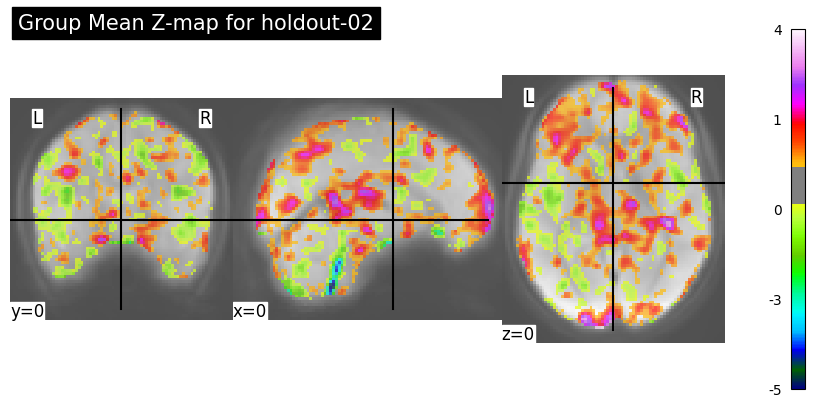

Threshold: 2.576
Thresholded the group-task-mean Z-map
Fetched resampled atlas map, labels, and coordinates
Applied atlas on Z-map
Obtained group ROIs mask, labels, and coordinates


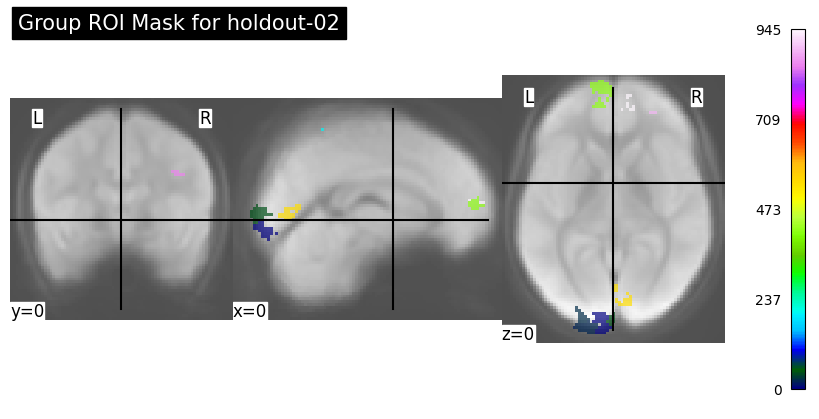

36 ROIs found
Subjects completed:
22847, 22860, 22862, 22873, 22906, 22956, 23010, 23028, 23044, 23257, 23261, 23294, 23303, 23314, 23317, 23362, 23407, 23432, 23442, 23483, 23485, 23501, 23524, 23532, 23534, 23559, 23568, 23572, 23584, 23622, 23629, 23631, 23664, 23749, 23779, 23842, 23855, 23865, 23871, 23883, 23910, 23979, 23985, 23986, 23987, 23991, 23996, 24004, 24015, 24033, 24038, 24046, 24050, 24067, 24073, 24091, 24106, 24115, 24118, 24139, 24146, 24148, 24151, 24182, 24197, 24198, 24217, 24236, 24275, 24353, 22172, 20131, 20209, 21214, 21508, 22295, 22346, 22353, 22365, 22366, 22380, 22381, 22475, 22482, 22487, 22623, 22686, 22687, 22727, 
Created ML Features table
Shape of ML Dataset: (89, 667)


,participant_id,LH_VisCent_Striate_1,LH_VisCent_Striate_2,LH_VisCent_Striate_3,LH_VisCent_Striate_4,LH_VisCent_ExStr_8,LH_VisCent_ExStr_10,LH_VisCent_ExStr_13,LH_VisCent_ExStr_19,LH_VisCent_ExStr_21,...,RH_ContB_PFClv_8_to_RH_DefaultA_PFCm_6,RH_ContB_PFClv_8_to_RH_DefaultA_PFCm_8,RH_ContB_PFClv_8_to_RH_DefaultB_PFCd_1,RH_ContB_PFClv_8_to_RH_DefaultB_PFCd_2,RH_DefaultA_PFCm_6_to_RH_DefaultA_PFCm_8,RH_DefaultA_PFCm_6_to_RH_DefaultB_PFCd_1,RH_DefaultA_PFCm_6_to_RH_DefaultB_PFCd_2,RH_DefaultA_PFCm_8_to_RH_DefaultB_PFCd_1,RH_DefaultA_PFCm_8_to_RH_DefaultB_PFCd_2,RH_DefaultB_PFCd_1_to_RH_DefaultB_PFCd_2
0,sub-022847,0.021243442256541106,-0.004595554203088333,0.10042768698188059,0.0,0.17383129750400686,0.37945977401808567,0.0019050691515517374,-0.02070677807690062,-0.2675733438347271,...,0.391390990534571,0.05955134357466338,0.005102306193580471,-0.002693421557685044,0.2935635768554235,0.31388850459168516,-0.10314043566649854,0.14797149925625666,0.3482068903399582,0.2743537113641294
2,sub-022862,0.41538574588516747,0.02492103972463725,0.1501819699756768,-0.0019987898505007817,1.0556925192206146,1.5326767338061023,0.061735106358087495,0.016524875614429713,0.13890087653363148,...,0.22478661444556505,-0.15146574144219932,0.3079473837695226,0.013936645330216626,-0.03655100002555322,0.1609148720988594,-0.15675359006260975,0.19004369088171835,0.4398290896990865,0.38111062640682064
71,sub-020131,0.47379109594557123,0.8170206455510838,0.485612469629877,0.8538781959149505,0.27360891098529827,1.1350478747594486,0.5645074322737895,0.344940425144491,0.5789885759241968,...,0.2971457902146769,0.1642629809800185,0.6421422267809516,0.23945290348166487,0.08933134126821254,0.1009961403580019,-0.263211549563663,0.16411514061683208,0.27057424878726755,-0.1418623112735691
4,sub-022906,0.08066008251866469,-0.03601315620257078,0.1967443623697075,0.0,0.36775075278589214,0.3837061322733828,0.016647962999095375,-0.023430783221478194,0.13521335698385603,...,0.371196761059369,-0.04662610600512274,0.2152810027999451,0.18378457605119097,0.13147813229766656,-0.032607221428956244,0.04725367070167053,0.1413497357772833,0.3416397773503231,0.40255883414189364
84,sub-022487,-0.2899685546863858,0.05565228229499604,-0.17954136346482882,-0.057203587339490006,0.2812146665908675,0.06467983854898078,0.09078152421095628,0.008203352628519948,0.5020099068369089,...,0.0039073241920396925,-0.03540050578643277,0.35289188077502315,-0.007163024101169747,0.10074729108576214,0.09511053233467721,-0.1747838512453612,0.10335368458737013,0.08927059701736662,0.5159393143365433



Holdout ID: 03
Computed group mean task-fmri
Subjects completed:
23044, 23342, 23314, 24089, 23559, 24004, 23883, 23735, 22906, 23532, 24240, 24145, 22354, 24115, 24275, 22346, 23925, 22532, 22871, 24091, 20209, 24021, 24353, 23601, 22536, 24276, 22381, 23923, 22686, 23972, 23317, 23392, 23386, 22831, 20131, 23534, 21508, 23257, 23892, 22487, 23572, 24236, 24039, 22380, 22687, 23779, 24146, 23690, 24106, 21100, 24127, 24217, 23987, 23568, 24139, 24151, 23303, 23631, 23842, 24029, 
Obtained first-level contrast maps
Created second-level design matrix
Obtained Group mean task maps


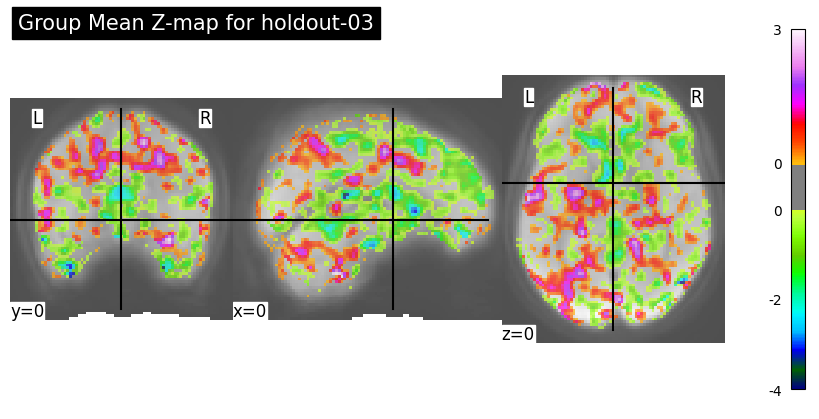

Threshold: 2.576
Thresholded the group-task-mean Z-map
Fetched resampled atlas map, labels, and coordinates
Applied atlas on Z-map
Obtained group ROIs mask, labels, and coordinates


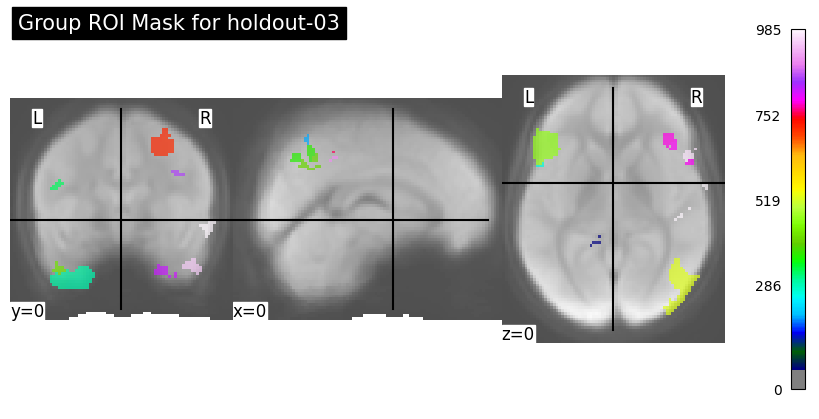

113 ROIs found
Subjects completed:
22734, 22818, 22829, 22847, 22860, 22862, 22873, 22956, 23010, 23014, 23028, 23072, 23123, 23261, 23294, 23353, 23362, 23376, 23381, 23382, 23407, 23432, 23442, 23480, 23483, 23485, 23494, 23501, 23524, 23545, 23567, 23584, 23622, 23629, 23664, 23749, 23762, 23822, 23855, 23865, 23871, 23878, 23910, 23946, 23971, 23979, 23985, 23986, 23991, 23996, 24015, 24017, 24022, 24033, 24038, 24040, 24046, 24050, 24067, 24073, 24118, 24142, 24148, 24182, 24197, 24198, 24212, 24260, 24270, 24300, 22172, 20725, 21214, 22268, 22281, 22286, 22295, 22353, 22365, 22366, 22475, 22477, 22482, 22494, 22587, 22600, 22623, 22630, 22727, 
Created ML Features table
Shape of ML Dataset: (89, 6442)


,participant_id,LH_VisCent_ExStr_2,LH_VisCent_ExStr_6,LH_VisCent_ExStr_29,LH_VisCent_ExStr_30,LH_VisPeri_ExStrInf_1,LH_VisPeri_ExStrInf_2,LH_VisPeri_ExStrInf_9,LH_SomMotA_15,LH_SomMotA_22,...,RH_DefaultC_PHC_2_to_RH_TempPar_3,RH_DefaultC_PHC_2_to_RH_TempPar_5,RH_DefaultC_PHC_2_to_RH_TempPar_6,RH_DefaultC_PHC_2_to_RH_TempPar_7,RH_TempPar_3_to_RH_TempPar_5,RH_TempPar_3_to_RH_TempPar_6,RH_TempPar_3_to_RH_TempPar_7,RH_TempPar_5_to_RH_TempPar_6,RH_TempPar_5_to_RH_TempPar_7,RH_TempPar_6_to_RH_TempPar_7
18,sub-023381,-1.4427471164026653,-0.7831225188658846,0.45614302215868424,0.28181802642510784,-0.754723388323688,-0.7447038095503767,-0.39184067249189686,0.9426062086135127,1.310202434371727,...,0.040521639758620866,0.03449417364587268,0.021821242197739572,-0.2426515359240432,0.04861881048869982,0.11676807792729517,-0.07054001963473344,0.16958666418473647,0.2673903377300665,0.005419945203885151
5,sub-022862,1.3285167135606541,0.9447142914369958,-0.09504599134560134,-0.4794616682627926,0.3826354752159349,0.39993458281897826,-0.9754537424631378,-0.7940299492151471,-1.162327104370223,...,0.1458101447920392,-0.13721583141242685,0.1497480627119173,0.02573906580994041,0.08165309715222298,0.2109825608191901,0.019942431640484596,0.2732960826826837,0.07082497511894899,-0.06147234410761471
52,sub-024022,1.1118726064604516,1.1817015874921544,1.9394872420461224,0.8251963929868814,-0.02100683578282011,0.35835249552085935,-0.20514944408515726,-0.6651483617894983,-0.08832080808795,...,0.16156887756147187,0.030996378098567277,-0.021111055564859038,-0.25399748466655697,0.11680042440867633,0.2774169817372852,0.1246045430856982,0.2425898754241559,0.03800068777251703,0.24280711462788948
19,sub-023382,-0.08401251873087706,-0.9642962465198381,0.6875325978499192,0.6850813270811206,0.059955347308823785,0.05537975299874705,-0.13365450184188452,0.8126397130933981,0.047291317503828666,...,0.20578499214982868,-0.21343955031790596,-0.06387461050132158,-0.0353249933854448,0.24042990409670514,0.14602320346951705,0.14463461305079695,0.19775838235156262,-0.01405652112884562,0.1792878814628331
68,sub-024270,-0.8519810788927846,-0.6772699827249661,-0.5553339146540714,-0.8240490732238978,-0.9625971601565981,-0.38464283007432254,-1.1080230007944412,0.42801364392321667,0.5905555461276637,...,-0.014546053908618317,0.1407005569595179,0.1797882728410719,0.014602003269237536,-0.021057038688339573,0.2364766692376886,0.07030171792064553,-0.09239190609813104,-0.043358493051584,0.20148373162902908



Holdout ID: 04
Computed group mean task-fmri
Subjects completed:
23855, 22494, 23442, 24106, 21100, 23123, 22831, 20725, 23910, 23842, 23622, 22536, 22623, 24146, 23501, 22687, 22381, 24142, 22587, 22600, 23532, 22956, 22366, 22365, 22354, 24197, 24240, 23480, 22727, 23991, 24089, 22172, 24270, 22487, 24073, 24145, 23735, 23629, 24091, 24148, 23985, 23762, 23257, 23572, 23014, 22847, 24198, 23878, 23381, 22686, 24039, 23749, 24017, 22286, 23690, 23883, 24300, 24217, 23567, 23925, 
Obtained first-level contrast maps
Created second-level design matrix
Obtained Group mean task maps


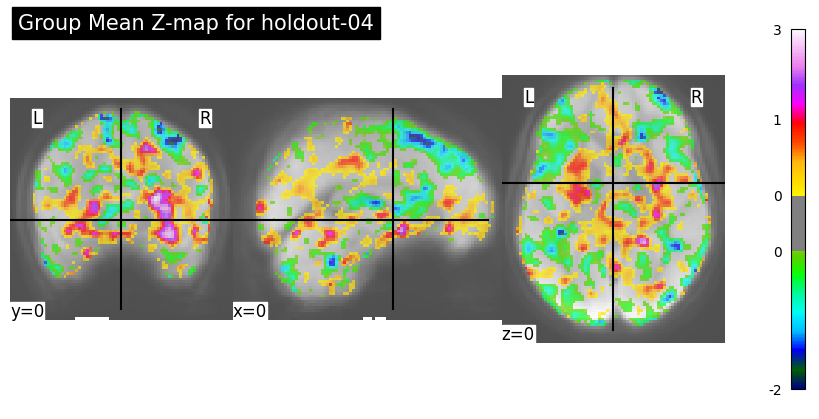

Threshold: 2.576
Thresholded the group-task-mean Z-map
Fetched resampled atlas map, labels, and coordinates
Applied atlas on Z-map
Obtained group ROIs mask, labels, and coordinates


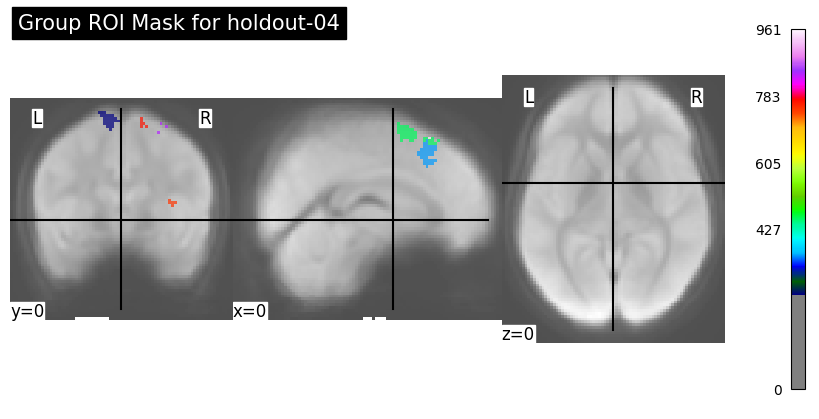

31 ROIs found
Subjects completed:
22734, 22818, 22829, 22860, 22862, 22871, 22873, 22906, 23010, 23028, 23044, 23072, 23261, 23294, 23303, 23314, 23317, 23342, 23353, 23362, 23376, 23382, 23386, 23392, 23407, 23432, 23483, 23485, 23494, 23524, 23534, 23545, 23559, 23568, 23584, 23601, 23631, 23664, 23779, 23822, 23865, 23871, 23892, 23923, 23946, 23971, 23972, 23979, 23986, 23987, 23996, 24004, 24015, 24021, 24022, 24029, 24033, 24038, 24040, 24046, 24050, 24067, 24115, 24118, 24127, 24139, 24151, 24182, 24212, 24236, 24260, 24275, 24276, 24353, 20131, 20209, 21214, 21508, 22268, 22281, 22295, 22346, 22353, 22380, 22475, 22477, 22482, 22532, 22630, 
Created ML Features table
Shape of ML Dataset: (89, 497)


,participant_id,LH_SalVentAttnA_FrMed_7,LH_ContB_PFCmp_2,LH_DefaultB_IPL_2,LH_DefaultB_IPL_5,LH_DefaultB_PFCd_9,LH_DefaultB_PFCd_11,LH_TempPar_10,LH_TempPar_12,LH_TempPar_13,...,RH_DefaultA_IPL_2_to_RH_DefaultA_IPL_4,RH_DefaultA_IPL_2_to_RH_DefaultA_IPL_7,RH_DefaultA_IPL_2_to_RH_DefaultB_PFCd_7,RH_DefaultA_IPL_2_to_RH_DefaultB_PFCd_8,RH_DefaultA_IPL_4_to_RH_DefaultA_IPL_7,RH_DefaultA_IPL_4_to_RH_DefaultB_PFCd_7,RH_DefaultA_IPL_4_to_RH_DefaultB_PFCd_8,RH_DefaultA_IPL_7_to_RH_DefaultB_PFCd_7,RH_DefaultA_IPL_7_to_RH_DefaultB_PFCd_8,RH_DefaultB_PFCd_7_to_RH_DefaultB_PFCd_8
60,sub-024050,0.35819177665152113,-1.2895578745357192,-1.4964008680142717,-0.3731935361035777,-1.2151918421053896,-1.1070087395955792,-0.5174564085421797,-1.4538473056749739,-0.7351319422659676,...,0.42948721458978534,-0.030689839618362108,-0.0007560089735818178,0.13241181277107278,0.420942553153696,-0.1260281467265385,0.013802435273942225,0.3038623959685027,-0.2071073701173509,0.23386883827203644
33,sub-023568,-0.3000612796770169,-0.29692935099726464,0.2604003935273579,0.13933688024736685,0.14605834595213596,0.14523527222797603,-0.27299905487068715,0.1111401759889906,0.46035416409447355,...,0.29756311351566933,-0.07069267497412515,-0.27376099296115786,0.13814366987602986,0.31384632087907965,0.13184900246837816,0.09321959748853671,0.06663323368605947,0.21869638958378518,0.10105871823651326
83,sub-022380,0.820348962357665,0.01758380979075919,-0.25803755534049844,-0.3314311098441506,-0.3342615612717659,-0.8733201625201812,-0.43263644813139135,-1.0656145268436807,-0.17128874349747847,...,0.24220730196896842,0.07336042610336348,-0.10514393630673165,0.042834495795540654,0.38114255336832265,-0.04374422973268363,0.20209865577354688,0.07877163330923063,0.08929060305534507,0.024052702045062966
78,sub-022268,-0.3041027504033266,-0.26175117274181703,1.0145321301163515,0.2691438753720246,0.2489925957073463,-0.04094781812665693,1.0465531353820385,0.3631431444772971,0.3114966748902485,...,0.43029289469168597,0.09050697547465573,-0.05773284257284063,-0.020414825579416228,0.47011211354247195,0.08033740322830518,0.044843640347260856,-0.04306366114809563,0.19682352004640397,0.5196339690350148
5,sub-022871,0.47577693756680434,-0.2007601946089322,-1.058251280209681,-1.4339144230623646,-1.1485447443610342,-0.35527552060193407,-1.056594191913122,-1.173001920591872,-0.6850576309713359,...,0.29049823512572465,-0.004277531489107608,-0.20479096226712257,0.13827842205618587,0.20412034626025066,0.04888350027054567,-0.1544383402129895,0.05062404311899464,-0.15842932603393367,0.36354355975756786



Holdout ID: 05
Computed group mean task-fmri
Subjects completed:
23855, 23996, 23376, 24146, 21214, 23524, 23342, 23257, 22860, 24148, 23986, 23072, 23762, 22380, 24089, 23971, 23567, 23381, 23923, 23735, 22862, 23910, 22494, 23480, 23353, 23314, 22600, 23494, 24017, 24260, 24091, 24236, 24217, 24270, 23584, 23010, 24353, 22687, 23559, 24038, 23622, 23883, 23407, 23317, 24198, 22727, 23483, 24275, 22475, 23501, 22734, 21100, 23985, 24067, 22623, 23892, 22268, 23664, 22353, 23991, 
Obtained first-level contrast maps
Created second-level design matrix
Obtained Group mean task maps


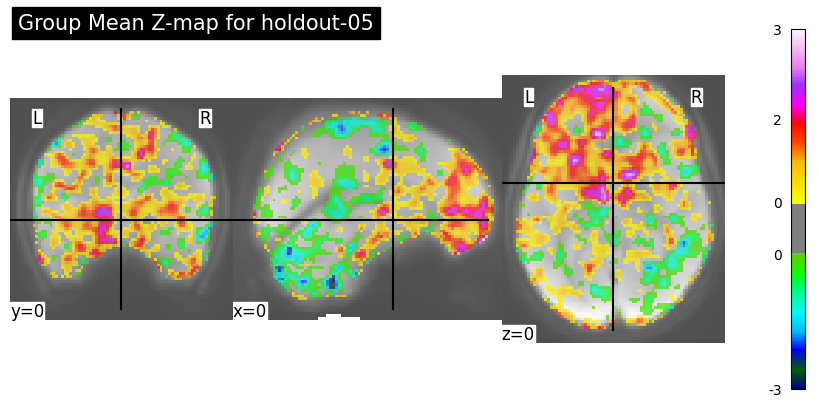

Threshold: 2.576
Thresholded the group-task-mean Z-map
Fetched resampled atlas map, labels, and coordinates
Applied atlas on Z-map
Obtained group ROIs mask, labels, and coordinates


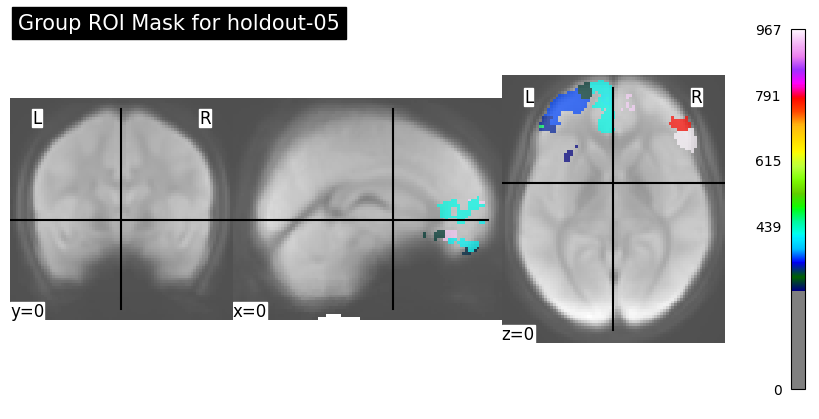

58 ROIs found
Subjects completed:
22818, 22829, 22831, 22847, 22871, 22873, 22906, 22956, 23014, 23028, 23044, 23123, 23261, 23294, 23303, 23362, 23382, 23386, 23392, 23432, 23442, 23485, 23532, 23534, 23545, 23568, 23572, 23601, 23629, 23631, 23690, 23749, 23779, 23822, 23842, 23865, 23871, 23878, 23925, 23946, 23972, 23979, 23987, 24004, 24015, 24021, 24022, 24029, 24033, 24039, 24040, 24046, 24050, 24073, 24106, 24115, 24118, 24127, 24139, 24142, 24145, 24151, 24182, 24197, 24212, 24240, 24276, 24300, 22172, 20131, 20209, 20725, 21508, 22281, 22286, 22295, 22346, 22354, 22365, 22366, 22381, 22477, 22482, 22487, 22532, 22536, 22587, 22630, 22686, 
Created ML Features table
Shape of ML Dataset: (89, 1712)


,participant_id,LH_SomMotA_4,LH_SomMotA_6,LH_SomMotA_11,LH_SomMotA_12,LH_SomMotA_13,LH_SomMotA_17,LH_SomMotA_19,LH_SomMotA_20,LH_SalVentAttnB_Ins_5,...,RH_DefaultA_PFCm_8_to_RH_DefaultB_PFCv_2,RH_DefaultA_PFCm_8_to_RH_DefaultB_PFCv_3,RH_DefaultA_PFCm_8_to_RH_DefaultB_PFCv_4,RH_DefaultA_PFCm_8_to_RH_DefaultB_PFCv_5,RH_DefaultB_PFCv_2_to_RH_DefaultB_PFCv_3,RH_DefaultB_PFCv_2_to_RH_DefaultB_PFCv_4,RH_DefaultB_PFCv_2_to_RH_DefaultB_PFCv_5,RH_DefaultB_PFCv_3_to_RH_DefaultB_PFCv_4,RH_DefaultB_PFCv_3_to_RH_DefaultB_PFCv_5,RH_DefaultB_PFCv_4_to_RH_DefaultB_PFCv_5
88,sub-022686,0.7590172735595975,0.759081077307162,0.727672047396288,0.9969417322688396,1.0427425546337337,0.6479336981017544,0.7595340703709298,0.8203581170449238,-0.4283619409573182,...,-0.008682602913820553,0.06355818720184374,-0.152515491340098,-0.2370016733797179,0.29291652190078543,-0.11044279744493131,-0.144989423822908,0.38572805015195183,-0.05643765360057727,0.1916555440635419
67,sub-024300,0.004008508945029907,-0.004748347070549017,0.5062792337468208,0.15381439874878766,0.5639635534708364,1.1142154383556258,1.1083822814030833,0.9813208933455959,-0.4451681111136627,...,0.07461626249675109,0.04055722727113283,-0.026257054025850168,0.2683151403669539,0.2875942076266305,0.08688578235416637,0.18937865231310314,0.25913231394329594,0.027505334298643765,0.4027455638841236
56,sub-024118,0.07738505102291669,-0.34902505722582133,-0.07890307399556713,0.4213226195581828,0.381438707742434,-0.08659558159620054,0.04890723896960778,0.3634952663518848,-0.1823109402657843,...,-0.02863703597191332,0.058077715942333755,-0.17907032237001108,0.12823257093987725,0.11910027790898403,0.1292404724687993,0.0565333948130468,0.27036964486254733,0.09564203217014171,0.43031635073903385
37,sub-023878,-0.06017533238981262,0.337850128243587,0.8274491812639869,0.30128731940498515,1.034462048139155,0.822077272981188,0.21374572566048405,1.0734390522144517,-0.38887731828071886,...,0.11504871181734662,0.11333137073892038,0.24586633960892604,-0.18537845116475132,0.13089375109108814,0.1520931891948758,0.30760172741569536,0.23798477794393497,-0.006419928218465914,0.14899273598387724
81,sub-022477,0.11262573812912847,0.5648902095073107,0.7537299046581504,0.28187318863580957,1.1784142667613164,0.41978111495429704,1.1920264830861027,1.1055745482895276,1.0592125686290201,...,0.017724922525947453,-0.00691319853759826,0.12949512349832124,-0.06129566499931625,0.1632868196362428,0.1364809607636095,0.15997803587884946,0.36391521255273057,0.010310753542041582,0.19849020740713788




 --- Consensus ROI counts at current stage ---
Valid iterations count: 5
Total unique ROIs seen: 326

Threshold 70%: 0 consensus ROIs
Threshold 80%: 0 consensus ROIs
Threshold 90%: 0 consensus ROIs


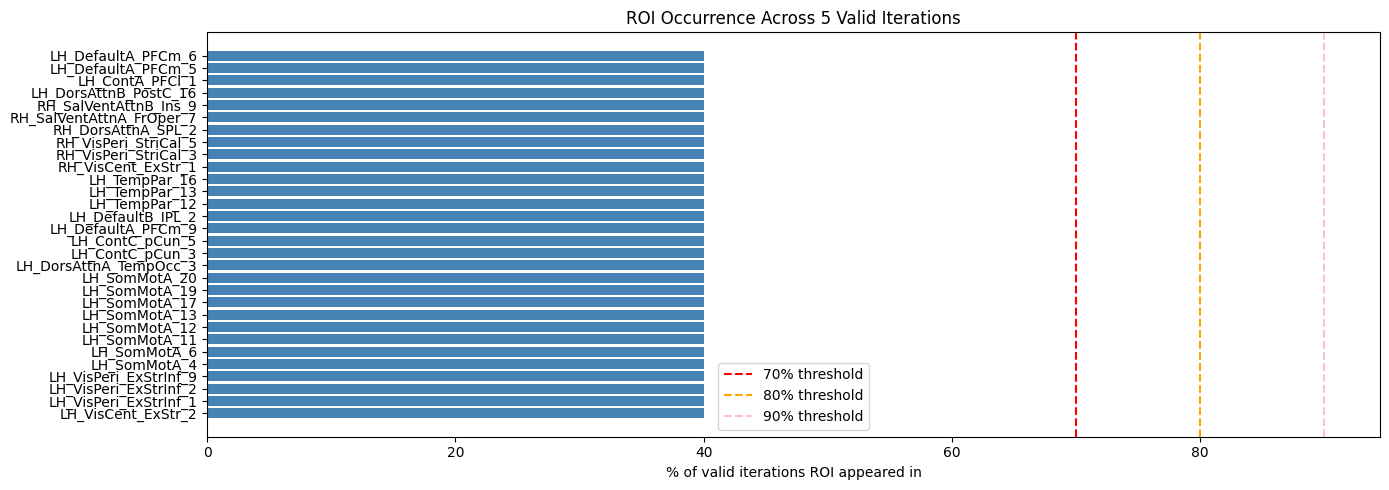

In [5]:
# --- load existing ROI occurrence counts if resuming ---------------------------
if os.path.exists(ROI_COUNTS_PATH):
    with open (ROI_COUNTS_PATH, 'r') as f:
        roi_occurrence = json.load(f)
else:
    roi_occurrence = {}

# --- load existing log to count valid iterations so far ------------------------
valid_iterations_count = 0
if os.path.exists(LOG_PATH):
    with open(LOG_PATH, 'r') as f:
        for line in f:
            entry = json.loads(line)
            if entry['valid']:
                valid_iterations_count += 1

print(f"Resuming... {valid_iterations_count} valid iterations already completed")
print(f"Alpha: {ALPHA1}, Height control: {HEIGHT_CONTROL1}, Cluster threshold: {CLUSTER_THRESHOLD3}")
print(f"{len(roi_occurrence)} unique ROIs seen so far\n")

# --- batch-wise iterations -----------------------------------------------------
batch = list(holdouts_info.items())[:5]

for key, val in batch:
    holdout_id = key.split('-')[1]
    feature_selection_config = {
        'alpha': ALPHA1,
        'height_control': HEIGHT_CONTROL1,
        'two-sided': True,
        'cluster_threshold':CLUSTER_THRESHOLD3
    }
    print(f"Holdout ID: {holdout_id}")

    # checking if holdout is done
    holdout_processed = False
    if os.path.exists(LOG_PATH):
        with open(LOG_PATH, 'r') as f:
            for line in f:
                entry = json.loads(line)
                if (entry['holdout_id']==holdout_id and 
                   entry['feature_selection_config'] == feature_selection_config):
                    holdout_processed = True
                    break
            if holdout_processed:
                print(f"Holdout {holdout_id} already processed")
                continue
                    
    holdout_i_path = os.path.join(HOLDOUTS30_PATH, key)
    
    # --- ROI identification ----------------------------------------------------
    group_mean_tfmri, group_mean_task_zmap = utils2.get_group_mean_maps(
        sub_list=val['slglm'], 
        phenotype_table=phenotype, 
        has_all_confounds=True,
        fl_contrast_name=CONTRAST_NAME, 
        fl_contrast_map_verbose=2,
        sl_verbose=0,
        show_sl_design_matrix=False,
        save_group_mean_tfmri=True, 
        save_group_mean_tfmri_path=holdout_i_path, 
        save_fl_contrasts=True, 
        save_fl_contrasts_path=holdout_i_path, 
        save_sl_design_matrix=True, 
        save_sl_design_matrix_path=holdout_i_path, 
        save_mean_task_zmap=True, 
        save_mean_task_zmap_path=holdout_i_path
    )
    utils2.plot_map(
        'roi', group_mean_task_zmap,
        f"Group Mean Z-map for {key}", group_mean_tfmri
    )
    
    group_ROIs_mask, group_ROIs_table, alpha_sub_directory = utils2.get_group_task_ROIs(
        group_mean_zmap=group_mean_task_zmap, 
        group_mean_fmri=group_mean_tfmri, 
        alpha=ALPHA1, height_control=HEIGHT_CONTROL1, two_sided=True, 
        cluster_threshold=CLUSTER_THRESHOLD3,
        atlas_name=ATLAS1, n_rois=N_ROIS1, yeo_networks=YN1, 
        save_thresholded_zmap=True, 
        save_thresholded_zmap_path=holdout_i_path, 
        save_ROIs_mask=True, 
        save_ROIs_mask_path=holdout_i_path
    )
    utils2.plot_map(
        'roi', group_ROIs_mask,
        f"Group ROI Mask for {key}", group_mean_tfmri
    )

    # check iteration validity
    num_rois = len(group_ROIs_table)
    if num_rois == 0:
        print("[SKIP] No ROIs found\n")
        continue
    print(f"{num_rois} ROIs found")

    # --- update ROI occurrence counts ------------------------------------------
    roi_names = group_ROIs_table['label'].values.tolist()
    for roi in roi_names:
        roi_occurrence[roi] = roi_occurrence.get(roi, 0) + 1

    with open(ROI_COUNTS_PATH, 'w') as f:
        json.dump(roi_occurrence, f, indent=2)

    valid_iterations_count += 1

    # --- feature extraction ----------------------------------------------------
    holdout_i_alpha_j_path = os.path.join(holdout_i_path, alpha_sub_directory)
    
    ml_dataset = utils2.create_ml_dataset(
        sub_list=val['ml'], 
        phenotype_table=phenotype, 
        has_all_confounds=True,
        group_ROIs_mask=group_ROIs_mask, 
        group_ROIs_table=group_ROIs_table, 
        fl_contrast_name=CONTRAST_NAME, 
        fl_alt_test=ALT_TEST, 
        save_zmaps=True, save_zmaps_path=holdout_i_path, 
        save_ROIs_zmaps=True, save_ROIs_zmaps_path=holdout_i_alpha_j_path,
        save_ROIs_rest_FC_matrices=True, save_ROIs_rest_FC_matrices_path=holdout_i_alpha_j_path, 
        save_table=True, save_name=f"{FEATURE_TABLE_NAME}_{key}.csv", 
        save_path=holdout_i_alpha_j_path
    )
    print(f"Shape of ML Dataset: {ml_dataset.shape}")
    display(ml_dataset.sample(5))
    print()

    # --- log the iteration ---------------------------------------------------------
    log_entry = {
        'holdout_id': holdout_id,
        'n_rois_found': num_rois,
        'valid': num_rois>0,
        'feature_selection_config': feature_selection_config
    }
    with open(LOG_PATH, 'a') as f:
        f.write(json.dumps(log_entry) + '\n')

# --- consensus ROI plot after each batch ---------------------------------------
if valid_iterations_count > 0:
    ROIs_per_threshold = {t: [] for t in CONSENSUS_THRESHOLDS}
    print("\n --- Consensus ROI counts at current stage ---")
    print(f"Valid iterations count: {valid_iterations_count}")
    print(f"Total unique ROIs seen: {len(roi_occurrence)}\n")

    for threshold in CONSENSUS_THRESHOLDS:
        consensus_rois = [
            roi for roi, count in roi_occurrence.items()
            if count/valid_iterations_count >= threshold
        ]
        print(f"Threshold {int(threshold*100)}%: {len(consensus_rois)} consensus ROIs")
        ROIs_per_threshold[threshold] = consensus_rois

    with open(CONSENSUS_ROIS_PATH, 'w') as f:
        json.dump(ROIs_per_threshold, f, indent=2)

    # bar chart of top ROIs by occurrence
    sorted_rois = sorted(roi_occurrence.items(), key=lambda x: x[1], reverse=True)
    top_n = min(30, len(sorted_rois)) # show top 30 or fewer
    top_names = [r[0] for r in sorted_rois[:top_n]]
    top_counts = [r[1] for r in sorted_rois[:top_n]]
    top_percentages  = [c/valid_iterations_count*100 for c in top_counts]

    fig, ax = plt.subplots(figsize=(14,5))
    bars = ax.barh(top_names, top_percentages, color='steelblue')
    ax.axvline(x=70, color='red', linestyle='--', label='70% threshold')
    ax.axvline(x=80, color='orange', linestyle='--', label='80% threshold')
    ax.axvline(x=90, color='pink', linestyle='--', label='90% threshold')
    ax.set_xlabel('% of valid iterations ROI appeared in')
    ax.set_title(f'ROI Occurrence Across {valid_iterations_count} Valid Iterations')
    ax.legend()
    plt.tight_layout()
    plt.show()